In [1]:
from spin_lattices import KagomeLattice, SpinLattice, ChainLattice, FactorLattice
from sympy.combinatorics import Permutation, PermutationGroup
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from igraph import Graph
import igraph
import itertools
import numpy.typing as npt
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from misc_utils import one, make_packed_configurations, make_unpacked_configurations
from sympy.combinatorics import Permutation, PermutationGroup
from pathlib import Path
from gcnn_naive import (
    mult_comb,
    SplitGroupConvNet2,
    SplitGroupConvNet,
    GConvG,
    GConvLattice,
    SplitGroupResConvNet,
)
from typing import Callable
import torch
from combinadics import Combination
import math
import lattice_symmetries as ls
import scipy.sparse.linalg
from datetime import datetime

from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import functools
import operator
import torch.nn as nn
from kagome_round import get_X_Y, hexagon_with_ear_starry_region, get_kagome27, get_kagome36, filter_permutations

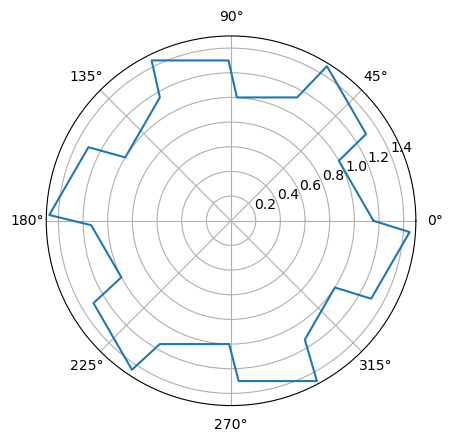

In [2]:
phi = np.linspace(0, 2 * np.pi, 100)
fig, ax = plt.subplots(subplot_kw={"projection": "polar"})
ax.plot(phi, hexagon_with_ear_starry_region(1)(phi))

<Axes: xlabel='emb_x', ylabel='emb_y'>

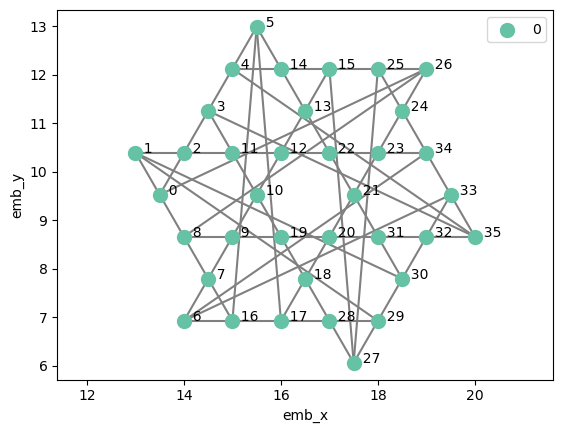

In [3]:
kagome36, generators_kagome36 = get_kagome36()
kagome36.plot()

<Axes: xlabel='emb_x', ylabel='emb_y'>

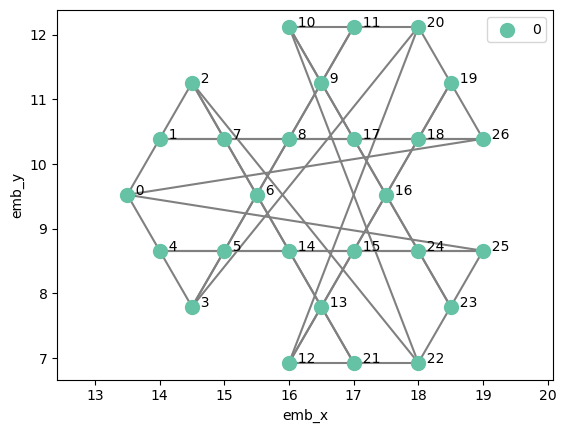

In [4]:
kagome27, generators_kagome27 = get_kagome27()
kagome27.plot()

In [5]:
assert (
    set(Permutation(g) for g in kagome36.get_automorphisms())
    - PermutationGroup(*generators_kagome36.values()).elements  # type: ignore
) == set()

In [6]:
assert (
    set(Permutation(g) for g in kagome27.get_automorphisms())
    - PermutationGroup(*generators_kagome27.values()).elements  # type: ignore
) == set()

In [17]:
system = HeisenbergJ1J2(
    lattice=kagome27,
    J1=1.0,
    use_symmetries=True,
    spin_inversion=None,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True,
)
system.get_eigenstates(1)

system_target = HeisenbergJ1J2(
    lattice=kagome36,
    J1=1.0,
    use_symmetries=True,
    spin_inversion=None,
    ground_state_cache_dir=Path("groundstates"),
    skip_symmetries_whitelist=True,
)
system_target.get_eigenstates(1)

2023-09-14 20:19:05.379 | WARNING  | heisenberg_hamiltonians:__init__:450 - Symmetries are not tested with KagomeLattice12x12_isotropic_factor_149-151-152-182-183-184-185-186-187-188-189-190-217-218-219-220-221-222-223-224-225-252-253-254-255-256-258, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-09-14 20:19:05.381 | DEBUG    | heisenberg_hamiltonians:__init__:482 - number_spins=27
2023-09-14 20:19:05.485 | DEBUG    | heisenberg_hamiltonians:__init__:492 - Symmetry group contains 216 elements
2023-09-14 20:19:05.908 | DEBUG    | heisenberg_hamiltonians:__init__:501 - Hilbert space dimension is 93610
2023-09-14 20:19:05.920 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice12x12_isotropic_factor_149-151-152-182-183-184-185-186-187-188-189-190-217-218-219-220-221-222-223-224-225-252-253-254-255-256-258-1.0-1.0-True-None-1.pickl

(array([-63.12622048]),
 array([[8.22952073e-12],
        [1.93068793e-11],
        [1.56266665e-10],
        ...,
        [1.76116039e-03],
        [1.54514717e-05],
        [1.54514717e-05]]))

In [29]:
def assert_equal_energies():
    lattice = kagome27
    symmetries = ls.Symmetries(
        [ls.Symmetry(g.array_form, sector=0) for g in generators_kagome27.values()]
    )

    # Constructing the basis
    basis = ls.SpinBasis(
        symmetries=symmetries,
        number_spins=system.number_spins,
        hamming_weight=system.number_spins // 2,
        spin_inversion=None,
    )
    basis.build()
    # Constructing the Hamiltonian
    expr_str = "2 (σ⁺₀ σ⁻₁ + σ⁺₁ σ⁻₀) + σᶻ₀ σᶻ₁"
    J1 = 1.0
    J2 = 1.0
    # fmt: off
    expr = (J1 * ls.Expr(expr_str, sites=lattice.kind_to_edges[1]) + 
            J2 * ls.Expr(expr_str, sites=lattice.kind_to_edges[2]))
    # fmt: on

    hamiltonian = ls.Operator(basis, expr)
    energy, _ = scipy.sparse.linalg.eigsh(hamiltonian, k=1, which="SA")
    assert np.isclose(energy, system.get_eigenstates(1)[0][0])


# assert_equal_energies()

In [30]:
# additional_generators = ["rotation", "flip"]

# model = SplitGroupConvNet2(
#     tx=generators_kagome27["tx"],
#     ty=generators_kagome27["ty"],
#     filter1_sites=[14, 15, 16, 17, 8, 6, 13, 24, 18, 9, 7, 5],
#     additional_generators=[generators_kagome27[gen] for gen in additional_generators],
#     filter1_width=1,
#     filter1_height=1,
# )

# model_target = SplitGroupConvNet2(
#     tx=generators_kagome36["tx"],
#     ty=generators_kagome36["ty"],
#     filter1_sites=[10, 19, 20, 21, 22, 12, 13, 11, 9, 18, 31, 23],
#     additional_generators=[generators_kagome36[gen] for gen in additional_generators],
#     filter1_width=1,
#     filter1_height=1,
# )

# model_target.load_state_dict(model.state_dict())

In [31]:
# kagome27.plot(spins=list(model.layer1.filter_idxs))

In [32]:
# kagome36.plot(spins=list(model_target.layer1.filter_idxs))

In [33]:
X, Y = get_X_Y(system, sample=10000)
X_target, Y_target = get_X_Y(system_target, sample=10000)

In [17]:
# Initialize the model
additional_generators = ["rotation", "flip"]
# coeff = functools.reduce(
#     operator.mul, [generators_kagome27[g].order() for g in additional_generators], 1
# ) * 3
# print(coeff)

# channels = [16 * 12 // coeff, 32 * 12 // coeff, 64 * 12 // coeff]
# filter_sizes = [(1, 1), (2, 2), (2, 2)]

extend_filter1 = (1, 1)
filter_size = (2, 2)
channels = 4 * 4
blocks = 16

# model_old = SplitGroupConvNet2(
#     tx=generators_kagome27["tx"],
#     ty=generators_kagome27["ty"],
#     filter1_sites=[14, 15, 16, 17, 8, 6, 13, 24, 18, 9, 7, 5],
#     additional_generators=[generators_kagome27[gen] for gen in additional_generators],
#     filter1_width=filter_sizes[0][0],
#     filter1_height=filter_sizes[0][1],
#     filter2_width=filter_sizes[1][0],
#     filter2_height=filter_sizes[1][1],
#     channels1=channels[0],
#     channels2=channels[1],
# )

# model_target = SplitGroupConvNet2(
#     tx=generators_kagome36["tx"],
#     ty=generators_kagome36["ty"],
#     filter1_sites=[10, 19, 20, 21, 22, 12, 13, 11, 9, 18, 31, 23],
#     additional_generators=[generators_kagome36[gen] for gen in additional_generators],
#     filter1_width=filter_sizes[0][0],
#     filter1_height=filter_sizes[0][1],
#     filter2_width=filter_sizes[1][0],
#     filter2_height=filter_sizes[1][1],
#     channels1=channels[0],
#     channels2=channels[1],
# )

model = SplitGroupResConvNet(
    tx=generators_kagome27["tx"],
    ty=generators_kagome27["ty"],
    filter1_sites=[14, 15, 16, 17, 8, 6, 13, 24, 18, 9, 7, 5],
    additional_generators=[generators_kagome27[gen] for gen in additional_generators],
    extend_filter1=extend_filter1,
    filter_size=filter_size,
    channels=channels,
)

model_target = SplitGroupResConvNet(
    tx=generators_kagome36["tx"],
    ty=generators_kagome36["ty"],
    filter1_sites=[10, 19, 20, 21, 22, 12, 13, 11, 9, 18, 31, 23],
    additional_generators=[generators_kagome36[gen] for gen in additional_generators],
    extend_filter1=extend_filter1,
    filter_size=filter_size,
    channels=channels,
)


lr = 1e-2


# Check if a GPU is available and if not, use a CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Move the model to the device (GPU or CPU)
model.to(device)

# Create a TensorDataset from your inputs X and Y
dataset = TensorDataset(X, Y)

# Create a DataLoader for your dataset with a batch size of 32 and shuffling
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Define a loss function - Mean Squared Error (MSE) for regression
criterion = torch.nn.MSELoss()

# Define an optimizer - Adam
optimizer = optim.Adam(model.parameters(), lr=lr)  # Learning rate

# Number of epochs (iterations over the entire dataset)
epochs = 10

# Create a SummaryWriter instance for TensorBoard
# writer = SummaryWriter(
#     log_dir=(
#         f"experiments/2023_07_03/{datetime.now().strftime('%H_%M_%S')}"
#         f"ch=_{','.join(map(str, channels))}_{','.join(additional_generators)}_{lr=}_{filter_sizes=}"
#     )
# )

writer = SummaryWriter(
    log_dir=(
        f"experiments/2023_07_04/{datetime.now().strftime('%H_%M_%S')}"
        f"ch=_{channels}_{','.join(additional_generators)}_{lr=}_{filter_size=}_{filter_size_head=}_{blocks=}"
    )
)
for epoch in range(epochs):
    running_loss = 0.0
    for action_index, data in enumerate(dataloader, 0):
        # Get the inputs and move them to the specified device
        inputs, log_amplitudes = data
        inputs, log_amplitudes = inputs.to(device), log_amplitudes.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # weights = torch.exp(2 * log_amplitudes)
        # weights = weights / torch.sum(weights)

        # Compute loss
        loss = (
            # weights @
            criterion(outputs, log_amplitudes.view(-1, 1))
        )  # Reshape labels to match output shape

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Collect loss
        running_loss += loss.item()

    # Add average loss per epoch to TensorBoard
    writer.add_scalar("Training Loss", running_loss / len(dataloader), epoch)

    # Calculate overlaps and add them to TensorBoard
    overlap_train = overlap(torch.exp(model(X).view(-1)), torch.exp(Y))
    # overlap_test = overlap(torch.exp(model(X_test).view(-1)), torch.exp(Y_test))
    model_target.load_state_dict(model.state_dict())
    overlap_target = overlap(
        torch.exp(model_target(X_target).view(-1)), torch.exp(Y_target)
    )

    writer.add_scalar("Overlap Train", overlap_train, epoch)
    # writer.add_scalar('Overlap Test', overlap_test, epoch)
    writer.add_scalar("Overlap Target", overlap_target, epoch)

writer.close()
print("Finished Training")

Finished Training


In [18]:
sum(p.numel() for p in model.parameters())

24785